In [387]:
import gdsfactory as gf
import numpy as np
import components as comp
import importlib

In [388]:
importlib.reload(comp)
gf.clear_cache()

In [389]:
c = gf.Component('TOP')

## Fiber bonding

In [390]:
wb = c << comp.wirebondingFiberBondingTemplate()

## adding y branches

In [391]:
## grating couplers connectors
#y1 = c << comp.yEbeam()
y2 = c << comp.yEbeam()
#y3 = c << comp.yEbeam()
y4 = c << comp.yEbeam()
#y1.rotate(90)
y2.rotate(-90)
#y3.rotate(90)
y4.rotate(-90)

#y1.x = (wb['o12'].x + wb['o13'].x)/2
#y1.y = wb['o9'].y - 100
#y3.x = (wb['o12'].x + wb['o13'].x)/2
#y3.y = wb['o9'].y - 100

y2.x = wb['o12'].x 
y2.y = 4211

y4.x = wb['o13'].x
y4.y = 4211

## Adding Bragg gratings

In [392]:
Nbg1 = 45
N2bg1 = 104
pds = np.array([320,322, 318,316])
bg1 = c << comp.bragg(Nbg1, pds[0])
bg2 = c << comp.bragg(N2bg1, pds[0])
bg3 = c << comp.bragg(N2bg1, pds[0])
bg4 = c << comp.bragg(Nbg1, pds[0])

bg5 = c << comp.bragg(45, pds[1])
bg6 = c << comp.bragg(104, pds[1])
bg7 = c << comp.bragg(104, pds[1])
bg8 = c << comp.bragg(45, pds[1])

bg9 = c << comp.bragg(45, pds[2]) #2
bg10 = c << comp.bragg(104, pds[2])
bg11 = c << comp.bragg(104, pds[2])
bg12 = c << comp.bragg(45, pds[2])

bg13 = c << comp.bragg(45, pds[3])
bg14 = c << comp.bragg(104, pds[3])
bg15 = c << comp.bragg(104, pds[3])
bg16 = c << comp.bragg(45, pds[3])


## Rotating gratings

In [393]:
bgs = [bg1, bg2, bg3, bg4, bg5, bg6, bg7, bg8, 
       bg9, bg10, bg11, bg12, bg13, bg14, bg15, bg16]

for bg in bgs:
    bg.rotate(-90)

## Positioning Bragg gratings

In [394]:
## positioning
pds = pds/1e3
bg1.x = (wb['o11'].x + wb['o12'].x)/2 + 80
bg1.y = y2['o2'].y - 100

bg2.rotate(180)
bg2.x = bg1.x
bg2.y = bg1.y - (Nbg1 + N2bg1) * pds[0] / 2 - pds[0]

bg3.x = bg2.x
bg3.y = bg2.y - (N2bg1 + N2bg1) * pds[0] / 2 - pds[0]

bg4.rotate(180)
bg4.x = bg3.x
bg4.y = bg3.y - (Nbg1 + N2bg1) * pds[0] / 2 - pds[0]
## second set
bg5.x = (wb['o12'].x + wb['o13'].x)/2 - 80
bg5.y = y2['o2'].y - 100

bg6.rotate(180)
bg6.x = bg5.x
bg6.y = bg5.y - (Nbg1 + N2bg1) * pds[1] / 2 - pds[1]

bg7.x = bg6.x
bg7.y = bg6.y - (N2bg1 + N2bg1) * pds[1] / 2 - pds[1]

bg8.rotate(180)
bg8.x = bg7.x
bg8.y = bg7.y - (Nbg1 + N2bg1) * pds[1] / 2 - pds[1]

## third set
bg9.x = (wb['o12'].x + wb['o13'].x)/2 + 80
bg9.y = y4['o2'].y - 100

bg10.rotate(180)
bg10.x = bg9.x
bg10.y = bg9.y - (Nbg1 + N2bg1) * pds[2] / 2 - pds[2]

bg11.x = bg10.x
bg11.y = bg10.y - (N2bg1 + N2bg1) * pds[2] / 2 - pds[2]

bg12.rotate(180)
bg12.x = bg11.x
bg12.y = bg11.y - (Nbg1 + N2bg1) * pds[2] / 2 - pds[2]

## fourth set
bg13.x = (wb['o13'].x + wb['o14'].x)/2 - 80
bg13.y = y4['o2'].y - 100

bg14.rotate(180)
bg14.x = bg13.x
bg14.y = bg13.y - (Nbg1 + N2bg1) * pds[3] / 2 - pds[3]

bg15.x = bg14.x
bg15.y = bg14.y - (N2bg1 + N2bg1) * pds[3] / 2 - pds[3]

bg16.rotate(180)
bg16.x = bg15.x
bg16.y = bg15.y - (Nbg1 + N2bg1) * pds[3] / 2 - pds[3]


## Adding phase shifers 1000 $\mu$m

In [395]:
ps1 = c << comp.phaseShifter1000u()
ps1.x = 720 + 1637.1/2
ps1.y = 1850
ps2 = c << comp.phaseShifter1000u()
ps2.mirror(p1=(0,0), p2=(0,1)) #flip horizontal
ps2.y = ps1.y 
ps2.x = -(500 + 1637.1/2)
ps3 = c << comp.phaseShifter1000u()
ps3.x = ps1.x
ps3.y = 650
ps4 = c << comp.phaseShifter1000u2x2()
ps4.mirror(p1=(0,0), p2=(0,1)) #flip horizontal
ps4.x = ps2.x 
ps4.y = 650

## Adding a fifth phase shifter to be tested separately

In [396]:
ps5 = c << comp.phaseShifter1000u2x2()


ps5.mirror(p1=(0,0), p2=(0,1)) #flip horizontal

ps5.x = ps2.x - 1483 - 260.4

ps5.y = ps1.y + 1200

## Photonics connections

#### Connecting Bragg gratings to y branches

In [397]:
## grating couplers
route1 = gf.routing.route_single(
    c,
    wb['o12'],
    y2.ports['o1'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
)
'''
route2 = gf.routing.route_single(
    c,
    wb['o13'],
    y1.ports['o2'],
    radius=5,
    start_straight_length=10,
    cross_section='strip',
)'''

route3 = gf.routing.route_single(
    c,
    wb['o13'],
    y4.ports['o1'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
)
'''
route4 = gf.routing.route_single(
    c,
    wb['o15'],
    y3.ports['o2'],
    radius=5,
    start_straight_length=10,
    cross_section='strip',
)'''
'''## input splitters connection
route5 = gf.routing.route_single(
    c,
    y2.ports['o1'],
    y1.ports['o1'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
)

route6 = gf.routing.route_single(
    c,
    y4.ports['o1'],
    y3.ports['o1'],
    radius=5,
    start_straight_length=10,
    cross_section='strip',
)'''

"## input splitters connection\nroute5 = gf.routing.route_single(\n    c,\n    y2.ports['o1'],\n    y1.ports['o1'],\n    radius=5,\n    cross_section='strip',\n    start_straight_length=10,\n)\n\nroute6 = gf.routing.route_single(\n    c,\n    y4.ports['o1'],\n    y3.ports['o1'],\n    radius=5,\n    start_straight_length=10,\n    cross_section='strip',\n)"

#### Bragg gratings connections

In [398]:
## first set
routey_bg1 = gf.routing.route_single(
    c,
    y2.ports['o2'],
    bg1.ports['o1'],
    radius=5,
    start_straight_length=5,
    cross_section='strip',
)
route_bg1_2 = gf.routing.route_single(
    c,
    bg1.ports['o2'],
    bg2.ports['o2'],
    cross_section='strip',
)
route_bg2_3 = gf.routing.route_single(
    c,
    bg2.ports['o1'],
    bg3.ports['o1'],
    cross_section='strip',
)
route_bg3_4 = gf.routing.route_single(
    c,
    bg3.ports['o2'],
    bg4.ports['o2'],
    cross_section='strip',
)

## second set
route_y_bg2 = gf.routing.route_single(
    c,
    y2.ports['o3'],
    bg5.ports['o1'],
    radius=5,
    start_straight_length=5,
    cross_section='strip',
)
route_bg5_6 = gf.routing.route_single(
    c,
    bg5.ports['o2'],
    bg6.ports['o2'],
    cross_section='strip',
)
route_bg6_7 = gf.routing.route_single(
    c,
    bg6.ports['o1'],
    bg7.ports['o1'],
    cross_section='strip',
)
route_bg7_8 = gf.routing.route_single(
    c,
    bg7.ports['o2'],
    bg8.ports['o2'],
    cross_section='strip',
)
## third set
route_y_bg9 = gf.routing.route_single(
    c,
    y4.ports['o2'],
    bg9.ports['o1'],
    radius=5,
    start_straight_length=5,
    cross_section='strip',
)
route_bg9_10 = gf.routing.route_single(
    c,
    bg9.ports['o2'],
    bg10.ports['o2'],
    cross_section='strip',
)
route_bg10_11 = gf.routing.route_single(
    c,
    bg10.ports['o1'],
    bg11.ports['o1'],
    cross_section='strip',
)
route_bg11_12 = gf.routing.route_single(
    c,
    bg11.ports['o2'],
    bg12.ports['o2'],
    cross_section='strip',
)
## fourth set
route_ybg13 = gf.routing.route_single(
    c,
    y4.ports['o3'],
    bg13.ports['o1'],
    radius=5,
    start_straight_length=5,
    cross_section='strip',
)
route_bg13_14 = gf.routing.route_single(
    c,
    bg13.ports['o2'],
    bg14.ports['o2'],
    cross_section='strip',
)
route_bg14_15 = gf.routing.route_single(
    c,
    bg14.ports['o1'],
    bg15.ports['o1'],
    cross_section='strip',
)
route_bg15_16 = gf.routing.route_single(
    c,
    bg15.ports['o2'],
    bg16.ports['o2'],
    cross_section='strip',
)

#### From Bragg gratings to phase shifters 1 and 2

In [399]:
route_bgs_ps2 = gf.routing.route_bundle(
    c,
    [bg4.ports['o1'],bg8.ports['o1']],
    [ps2.ports['o1'], ps2.ports['o2']],
    start_straight_length=200,
    cross_section='strip',
    path_length_matching_config={"element": 1, "loop_side":gf.routing.LoopSide.right, "loops": 1, "loop_position": gf.routing.LoopPosition.center}
)

route_bgs_ps1 = gf.routing.route_bundle(
    c,
    [bg12.ports['o1'],bg16.ports['o1']],
    [ps1.ports['o2'], ps1.ports['o1']],
    start_straight_length=200,
    cross_section='strip',
    path_length_matching_config={"element": 1, "loop_side":gf.routing.LoopSide.left, "loops": 1, "loop_position": gf.routing.LoopPosition.center}
)

#### from ps1 and ps2 to ps3

In [400]:
'''
route_ps1_2_ps3 = gf.routing.route_bundle(
    c,
    [ps1.ports['o3'], ps2.ports['o3']],
    [ps3.ports['o1'], ps3.ports['o2']],
    start_straight_length=200,
    cross_section='strip',
    #path_length_matching_config={"element": 0, "loop_side":gf.routing.LoopSide.left, "loops": 3, "loop_position": gf.routing.LoopPosition.start}
)
'''
route_ps1_ps2 = gf.routing.route_single(
    c,
    ps1.ports['o3'],
    ps3.ports['o1'],
    start_straight_length=300,
    cross_section='strip',
    steps = [
        {'dx': -300, 'dy': 0},
        {'dx': 0, 'dy': -300},
        {'dx': 150 + 372.1, 'dy': 0}, #due to path length matching
        {'dx': 0, 'dy': -150},
        {'dx': -150 - 372.1, 'dy': 0}, #due to path length matching
        {'dx': 0, 'y': ps3.ports['o1'].y},
    ]
)
route_ps2_ps3 = gf.routing.route_single(
    c,
    ps2.ports['o3'],
    ps3.ports['o2'],
    start_straight_length=300,
    cross_section='strip',
    steps = [
        {'dx': 800, 'dy': 0},
        {'dx': 0, 'dy': -300},
        {'dx': -150, 'dy': 0},
        {'dx': 0, 'dy': -150},
        {'dx': 150, 'dy': 0},
        {'dx': 0, 'y': ps3.ports['o2'].y},
    ]
)


In [401]:
(route_ps2_ps3.length - route_ps1_ps2.length)/1e3, ((route_ps2_ps3.length - route_ps1_ps2.length)/1e3)/2

(-4.656612873077393e-13, -2.3283064365386963e-13)

In [402]:
route_ps2_ps3.length/1e3

2570.023068

#### from ps3 to ps4 (unbalanced MZI with $\Delta L = 120.4 \mu m$)

In [403]:
y5 = c << comp.yEbeam()
y5.rotate(180)
y5.y = (ps4['o1'].y + ps4['o2'].y)/2
y5.x = ps3['o1'].x - 630

In [404]:
delta = 120.4
route_ps4_y5_upper = gf.routing.route_single(
    c,
    y5.ports['o2'],
    ps4.ports['o1'],
    
    cross_section='strip',
    steps =[
        {'dx': -20, 'dy': 0},
        {'dx': 0, 'y': ps4.ports['o1'].y},
    ]
)
route_ps4_y5_lower = gf.routing.route_single(
    c,
    y5.ports['o3'],
    ps4.ports['o2'],
    
    cross_section='strip',
    steps =[
        {'dx': -20, 'dy': 0},
        {'dx': 0, 'y': ps4.ports['o2'].y},
    ]
)

route_ps3_y5 = gf.routing.route_single(
    c,
    ps3.ports['o3'],
    y5.ports['o1'],
    start_straight_length=10,
    cross_section='strip',
    steps = [
        {'dx': -510, 'dy': 0},
        {'dx': 0, 'y': y5.ports['o1'].y}
    ]
)

#### ps4 to output gcs

In [405]:
route_ps4_out1 = gf.routing.route_single(
    c,
    ps4.ports['o3'],
    wb['o3'],
    start_straight_length=10,
    cross_section='strip',
    steps = [
                {'dx': 20, 'dy': 0},
                {'dx': 0, 'dy': -50},
                {'dx': -1750, 'dy': 0},
                {'dx': 0, 'dy': -2750},
                {'dx': 200, 'dy': 0},
                {'dx': 0, 'dy': -185.5 -20},
                {'dx': 20, 'dy': 0},
                {'dx': 0, 'dy': 185.5 + 20},
                {'x': wb['o3'].x, 'dy': 0}
            ]
    
)
diff = 426.39999999999964*1e-6 #diferenca entre o comprimento dos guias

route_ps4_out2 = gf.routing.route_single(
    c,
    ps4.ports['o4'],
    wb['o2'],
    start_straight_length=10,
    cross_section='strip',
    steps = [
            {'dx': 20, 'dy': 0},
            {'dx': 0, 'dy': 50},
            {'dx': -1820, 'dy': 0},
            {'dx': 0, 'dy': -3470},
            {'dx': 200, 'dy': 0},
            {'dx': 0, 'dy': -20},
            {'dx': 20, 'dy': 0},
            {'dx': 0, 'dy': 20},
            {'x': wb['o2'].x, 'dy': 0}
        ]
)




In [406]:
(route_ps4_out2.length/1e3 - route_ps4_out1.length/1e3)/2 

0.0

### Ps5 Mzi connections

In [407]:
## adding y branch to make a MZI

ymzi_test = c << comp.yEbeam()

ymzi_test.rotate(180)

ymzi_test.x = ps5.ports['o1'].x + 550

ymzi_test.y = ( ps5.ports['o1'].y + ps5.ports['o2'].y)/2

In [ ]:
route_y_gc = gf.routing.route_single(
    c,
    wb['o7'],
    ymzi_test.ports['o1'],
    start_straight_length=10,
    cross_section='strip',
    steps =[
        {'dx': 0, 'dy': 1860},
        {'dx': 1770, 'dy': 0},
        {'dx': 0, 'y': wb['o11'].y-64},
        {'dx': -1440, 'dy': 0},
        {'dx': 0, 'dy': 116},
        {'x': 0.5*(wb['o10'].x + wb['o11'].x),'dy': 0},
        {'dx':0, 'dy': -410},
        {'dx': -560, 'dy': 0},
        {'dx':0 ,'y': ymzi_test.ports['o1'].y},
        ]
)

route_ps5_y_upper = gf.routing.route_single(
    c,
    ymzi_test.ports['o2'],
    ps5.ports['o1'],
    cross_section='strip',
    steps =[
        {'dx': -20, 'dy': 0},
        {'dx': 0, 'y': ps5.ports['o1'].y},
    ]
    
    
)
route_ps5_y_lower = gf.routing.route_single(
    c,
    ymzi_test.ports['o3'],
    ps5.ports['o2'],
    cross_section='strip',
    steps =[
        {'dx': -20, 'dy': 0},
        {'dx': 0, 'y': ps5.ports['o2'].y},
    
        
    ]
)

route_ps5_gc = gf.routing.route_single(
    c,
    ps5.ports['o3'],
    wb['o11'],
    cross_section='strip',
    steps =[
        {'dx': 1220, 'dy': 0},
        {'dx': 0, 'dy': 1020},
        {'x': wb['o11'].x, 'dy': 0},   
    ]
)

route_ps5_gc_2 = gf.routing.route_single(
    c,
    ps5.ports['o4'],
    wb['o10'],
    cross_section='strip',
    steps =[
        {'dx': 1020, 'dy': 0},
        {'dx': 0, 'dy': 800},
        {'x': wb['o10'].x, 'dy': 0},   
    ]
)

In [409]:
(route_ps5_gc.length - route_ps5_gc_2.length)/1e3

631.0000000000005

## metal wiring

In [410]:
taper_length = 100
width = 86
tapers = []
for i in range(12):
    taper = c << gf.components.taper(
        length=taper_length,
        width1=width,
        width2=wb[f'e{i+1}'].width,   
        layer=(12, 0),
        port_names=('e_in', 'e_out'),
        port_types=('electrical', 'electrical'),
    )
    taper.connect('e_out', wb[f'e{i+1}'])
    tapers.append(taper)

for i in range(3):
    tapers[i].connect('e_out', wb[f'e{39-i}'])

    gf.routing.route_single_electrical(
        c, ps1.ports[f'e{i+1}'], tapers[i].ports['e_in'],
        cross_section='metal_routing',
        layer=(12, 0),
        width=width,
        
    )
    
for i in range(3):
    tapers[i+3].connect('e_out', wb[f'e{36-i}'])

    gf.routing.route_single_electrical(
        c, ps3.ports[f'e{i+1}'], tapers[i+3].ports['e_in'],
        cross_section='metal_routing',
        layer=(12, 0),
        width=width,
        
    )
    
for i in range(3):
    tapers[i+6].connect('e_out', wb[f'e{17-i}'])

    gf.routing.route_single_electrical(
        c, ps2.ports[f'e{i+1}'], tapers[i+6].ports['e_in'],
        cross_section='metal_routing',
        layer=(12, 0),
        width=width,
        
    )

for i in range(3):  
    tapers[i+9].connect('e_out', wb[f'e{14-i}'])

    gf.routing.route_single_electrical(
        c, ps4.ports[f'e{i+1}'], tapers[i+9].ports['e_in'],
        cross_section='metal_routing',
        layer=(12, 0),
        width=width,

    )


### additional phase shifter connections

tapers2 = []

for i in range(3):
    taper = c << gf.components.taper(
        length=taper_length,
        width1=width,
        width2=wb[f'e{i+1}'].width,   
        layer=(12, 0),
        port_names=('e_in', 'e_out'),
        port_types=('electrical', 'electrical'),
    )
    taper.connect('e_out', wb[f'e{i+20}']) #20 to 18
    tapers2.append(taper)


for i in range(3):  
    tapers2[i].connect('e_out', wb[f'e{20-i}'])

    gf.routing.route_single_electrical(
        c, ps5.ports[f'e{i+1}'], tapers2[i].ports['e_in'],
        cross_section='metal_routing',
        layer=(12, 0),
        width=width,

    )

### Strain circuit

In [411]:
## grating couplers connectors
#y1 = c << comp.yEbeam()
y2_s = c << comp.yEbeam()
#y3 = c << comp.yEbeam()
y4_s = c << comp.yEbeam()
#y1.rotate(90)
y2_s.rotate(90)
#y3.rotate(90)
y4_s.rotate(90)

#y1.x = (wb['o12'].x + wb['o13'].x)/2
#y1.y = wb['o9'].y - 100
#y3.x = (wb['o12'].x + wb['o13'].x)/2
#y3.y = wb['o9'].y - 100

y2_s.x = wb['o4'].x 
y2_s.y = wb['o4'].y + 113

y4_s.x = wb['o5'].x
y4_s.y = wb['o5'].y + 113

In [412]:
N = np.array([135,312,390,420,390,312,135])

pd = 320
bg1_s = c << comp.bragg(N[0], pd)
bg2_s = c << comp.bragg(N[1], pd)
bg3_s = c << comp.bragg(N[2], pd)
bg4_s = c << comp.bragg(N[3], pd)
bg5_s = c << comp.bragg(N[4], pd)
bg6_s = c << comp.bragg(N[5], pd)
bg7_s = c << comp.bragg(N[6], pd)

bg8_s = c << comp.bragg(N[0], pd)
bg9_s = c << comp.bragg(N[1], pd)
bg10_s = c << comp.bragg(N[2], pd)
bg11_s = c << comp.bragg(N[3], pd)
bg12_s = c << comp.bragg(N[4], pd)
bg13_s = c << comp.bragg(N[5], pd)
bg14_s = c << comp.bragg(N[6], pd)

bg15_s = c << comp.bragg(N[0], pd)
bg16_s = c << comp.bragg(N[1], pd)
bg17_s = c << comp.bragg(N[2], pd)
bg18_s = c << comp.bragg(N[3], pd)
bg19_s = c << comp.bragg(N[4], pd)
bg20_s = c << comp.bragg(N[5], pd)
bg21_s = c << comp.bragg(N[6], pd)

bg22_s = c << comp.bragg(N[0], pd)
bg23_s = c << comp.bragg(N[1], pd)
bg24_s = c << comp.bragg(N[2], pd)
bg25_s = c << comp.bragg(N[3], pd)
bg26_s = c << comp.bragg(N[4], pd)
bg27_s = c << comp.bragg(N[5], pd)
bg28_s = c << comp.bragg(N[6], pd)


In [413]:
bgs_s = [
    bg1_s, bg2_s, bg3_s, bg4_s, bg5_s, bg6_s, bg7_s,
    bg8_s, bg9_s, bg10_s, bg11_s, bg12_s, bg13_s, bg14_s,
    bg15_s, bg16_s, bg17_s, bg18_s, bg19_s, bg20_s, bg21_s,
    bg22_s, bg23_s, bg24_s, bg25_s, bg26_s, bg27_s, bg28_s
]

for bg in bgs_s:
    bg.rotate(90)

In [414]:
pd = 0.32

In [415]:
((N[0] + N[1]) * pd  + pd)/1e-6

np.float64(143360000.0)

In [416]:
N[0]*pd/2

np.float64(21.6)

In [417]:
## positioning

bg1_s.x = (wb['o3'].x + wb['o4'].x)/2 + 80
bg1_s.y = y2_s['o2'].y + 100

bg2_s.rotate(180)
bg2_s.x = bg1_s.x
bg2_s.y = bg1_s.y + (N[0] + N[1]) * pd/2  + pd

bg3_s.x = bg2_s.x
bg3_s.y = bg2_s.y + (N[1] + N[2]) * pd / 2 + pd

bg4_s.rotate(180)
bg4_s.x = bg3_s.x
bg4_s.y = bg3_s.y + (N[2] + N[3]) * pd / 2 + pd

bg5_s.x = bg4_s.x
bg5_s.y = bg4_s.y + (N[3] + N[4]) * pd / 2 + pd


bg6_s.rotate(180)
bg6_s.x = bg5_s.x
bg6_s.y = bg5_s.y + (N[4] + N[5]) * pd / 2 + pd

bg7_s.x = bg6_s.x
bg7_s.y = bg6_s.y + (N[5] + N[6]) * pd / 2 + pd

## second set


bg8_s.x = (wb['o4'].x + wb['o5'].x)/2 - 80
bg8_s.y = y2_s['o3'].y + 100

bg9_s.rotate(180)
bg9_s.x = bg8_s.x
bg9_s.y = bg8_s.y + (N[0] + N[1]) * pd/2  + pd

bg10_s.x = bg9_s.x
bg10_s.y = bg9_s.y + (N[1] + N[2]) * pd / 2 + pd

bg11_s.rotate(180)
bg11_s.x = bg10_s.x
bg11_s.y = bg10_s.y + (N[2] + N[3]) * pd / 2 + pd

bg12_s.x = bg11_s.x
bg12_s.y = bg11_s.y + (N[3] + N[4]) * pd / 2 + pd



bg13_s.rotate(180)
bg13_s.x = bg12_s.x
bg13_s.y = bg12_s.y + (N[4] + N[5]) * pd / 2 + pd

bg14_s.x = bg13_s.x
bg14_s.y = bg13_s.y + (N[5] + N[6]) * pd / 2 + pd

#third set

bg15_s.x = (wb['o4'].x + wb['o5'].x)/2 + 80
bg15_s.y = y2_s['o3'].y + 100


bg16_s.rotate(180)
bg16_s.x = bg15_s.x
bg16_s.y = bg15_s.y + (N[0] + N[1]) * pd/2  + pd

bg17_s.x = bg16_s.x
bg17_s.y = bg16_s.y + (N[1] + N[2]) * pd / 2 + pd

bg18_s.rotate(180)
bg18_s.x = bg17_s.x
bg18_s.y = bg17_s.y + (N[2] + N[3]) * pd / 2 + pd

bg19_s.x = bg18_s.x
bg19_s.y = bg18_s.y + (N[3] + N[4]) * pd / 2 + pd



bg20_s.rotate(180)
bg20_s.x = bg19_s.x
bg20_s.y = bg19_s.y + (N[4] + N[5]) * pd / 2 + pd

bg21_s.x = bg20_s.x
bg21_s.y = bg20_s.y + (N[5] + N[6]) * pd / 2 + pd

#fourth set


bg22_s.x = (wb['o5'].x + wb['o6'].x)/2 - 80
bg22_s.y = y2_s['o3'].y + 100


bg23_s.rotate(180)
bg23_s.x = bg22_s.x
bg23_s.y = bg22_s.y + (N[0] + N[1]) * pd/2  + pd

bg24_s.x = bg23_s.x
bg24_s.y = bg23_s.y + (N[1] + N[2]) * pd / 2 + pd

bg25_s.rotate(180)
bg25_s.x = bg24_s.x
bg25_s.y = bg24_s.y + (N[2] + N[3]) * pd / 2 + pd

bg26_s.x = bg25_s.x
bg26_s.y = bg25_s.y + (N[3] + N[4]) * pd / 2 + pd



bg27_s.rotate(180)
bg27_s.x = bg26_s.x
bg27_s.y = bg26_s.y + (N[4] + N[5]) * pd / 2 + pd

bg28_s.x = bg27_s.x
bg28_s.y = bg27_s.y + (N[5] + N[6]) * pd / 2 + pd


In [418]:
ps1_s = c << comp.phaseShifter1000u()
ps1_s.mirror(p1=(0,0), p2=(1,0)) 
ps1_s.x =  720 + 1637.1/2
ps1_s.y = -1750
ps2_s = c << comp.phaseShifter1000u()
ps2_s.mirror(p1=(0,0), p2=(1,0)) 
ps2_s.mirror(p1=(0,0), p2=(0,1)) #flip horizontal
ps2_s.y = ps1_s.y 
ps2_s.x = -(500 + 1637.1/2)
ps3_s = c << comp.phaseShifter1000u()
ps3_s.mirror(p1=(0,0), p2=(1,0)) 
ps3_s.x = ps1_s.x
ps3_s.y = -550
ps4_s = c << comp.phaseShifter1000u2x2()
ps4_s.mirror(p1=(0,0), p2=(1,0))
ps4_s.mirror(p1=(0,0), p2=(0,1)) #flip horizontal
ps4_s.x = ps2_s.x 
ps4_s.y = -550

In [419]:
## grating couplers
route1_s = gf.routing.route_single(
    c,
    wb['o4'],
    y2_s.ports['o1'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
)

route2_s = gf.routing.route_single(
    c,
    wb['o5'],
    y4_s.ports['o1'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
)


In [420]:
## first set (bg1 a bg7)
route_y_bg1_s = gf.routing.route_single(
    c,
    y2_s.ports['o2'],
    bg1_s.ports['o1'],
    radius=5,
    start_straight_length=5,
    cross_section='strip',
)
route_bg1_2_s = gf.routing.route_single(
    c,
    bg1_s.ports['o2'],
    bg2_s.ports['o2'],
    cross_section='strip',
)
route_bg2_3_s = gf.routing.route_single(
    c,
    bg2_s.ports['o1'],
    bg3_s.ports['o1'],
    cross_section='strip',
)
route_bg3_4_s = gf.routing.route_single(
    c,
    bg3_s.ports['o2'],
    bg4_s.ports['o2'],
    cross_section='strip',
)
route_bg4_5_s = gf.routing.route_single(
    c,
    bg4_s.ports['o1'],
    bg5_s.ports['o1'],
    cross_section='strip',
)
route_bg5_6_s = gf.routing.route_single(
    c,
    bg5_s.ports['o2'],
    bg6_s.ports['o2'],
    cross_section='strip',
)
route_bg6_7_s = gf.routing.route_single(
    c,
    bg6_s.ports['o1'],
    bg7_s.ports['o1'],
    cross_section='strip',
)

## second set (bg8 a bg14)
route_y_bg8_s = gf.routing.route_single(
    c,
    y2_s.ports['o3'],
    bg8_s.ports['o1'],
    radius=5,
    start_straight_length=5,
    cross_section='strip',
)
route_bg8_9_s = gf.routing.route_single(
    c,
    bg8_s.ports['o2'],
    bg9_s.ports['o2'],
    cross_section='strip',
)
route_bg9_10_s = gf.routing.route_single(
    c,
    bg9_s.ports['o1'],
    bg10_s.ports['o1'],
    cross_section='strip',
)
route_bg10_11_s = gf.routing.route_single(
    c,
    bg10_s.ports['o2'],
    bg11_s.ports['o2'],
    cross_section='strip',
)
route_bg11_12_s = gf.routing.route_single(
    c,
    bg11_s.ports['o1'],
    bg12_s.ports['o1'],
    cross_section='strip',
)
route_bg12_13_s = gf.routing.route_single(
    c,
    bg12_s.ports['o2'],
    bg13_s.ports['o2'],
    cross_section='strip',
)
route_bg13_14_s = gf.routing.route_single(
    c,
    bg13_s.ports['o1'],
    bg14_s.ports['o1'],
    cross_section='strip',
)

## third set (bg15 a bg21)
route_y_bg15_s = gf.routing.route_single(
    c,
    y4_s.ports['o2'],
    bg15_s.ports['o1'],
    radius=5,
    start_straight_length=5,
    cross_section='strip',
)
route_bg15_16_s = gf.routing.route_single(
    c,
    bg15_s.ports['o2'],
    bg16_s.ports['o2'],
    cross_section='strip',
)
route_bg16_17_s = gf.routing.route_single(
    c,
    bg16_s.ports['o1'],
    bg17_s.ports['o1'],
    cross_section='strip',
)
route_bg17_18_s = gf.routing.route_single(
    c,
    bg17_s.ports['o2'],
    bg18_s.ports['o2'],
    cross_section='strip',
)
route_bg18_19_s = gf.routing.route_single(
    c,
    bg18_s.ports['o1'],
    bg19_s.ports['o1'],
    cross_section='strip',
)
route_bg19_20_s = gf.routing.route_single(
    c,
    bg19_s.ports['o2'],
    bg20_s.ports['o2'],
    cross_section='strip',
)
route_bg20_21_s = gf.routing.route_single(
    c,
    bg20_s.ports['o1'],
    bg21_s.ports['o1'],
    cross_section='strip',
)

## fourth set (bg22 a bg28)
route_y_bg22_s = gf.routing.route_single(
    c,
    y4_s.ports['o3'],
    bg22_s.ports['o1'],
    radius=5,
    start_straight_length=5,
    cross_section='strip',
)
route_bg22_23_s = gf.routing.route_single(
    c,
    bg22_s.ports['o2'],
    bg23_s.ports['o2'],
    cross_section='strip',
)
route_bg23_24_s = gf.routing.route_single(
    c,
    bg23_s.ports['o1'],
    bg24_s.ports['o1'],
    cross_section='strip',
)
route_bg24_25_s = gf.routing.route_single(
    c,
    bg24_s.ports['o2'],
    bg25_s.ports['o2'],
    cross_section='strip',
)
route_bg25_26_s = gf.routing.route_single(
    c,
    bg25_s.ports['o1'],
    bg26_s.ports['o1'],
    cross_section='strip',
)
route_bg26_27_s = gf.routing.route_single(
    c,
    bg26_s.ports['o2'],
    bg27_s.ports['o2'],
    cross_section='strip',
)
route_bg27_28_s = gf.routing.route_single(
    c,
    bg27_s.ports['o1'],
    bg28_s.ports['o1'],
    cross_section='strip',
)

In [421]:
route_bgs_ps2_s = gf.routing.route_bundle(
    c,
    [bg7_s.ports['o2'],bg14_s.ports['o2']],
    [ps2_s.ports['o1'], ps2_s.ports['o2']],
    start_straight_length=200,
    cross_section='strip',
    path_length_matching_config={"element": 1, "loop_side":gf.routing.LoopSide.left, "loops": 1, "loop_position": gf.routing.LoopPosition.center}
)

route_bgs_ps1_s = gf.routing.route_bundle(
    c,
    [bg21_s.ports['o2'],bg28_s.ports['o2']],
    [ps1_s.ports['o2'], ps1_s.ports['o1']],
    start_straight_length=200,
    cross_section='strip',
    path_length_matching_config={"element": 1, "loop_side":gf.routing.LoopSide.right, "loops": 1, "loop_position": gf.routing.LoopPosition.center}
)

In [422]:


route_ps1_ps2_s = gf.routing.route_single(
    c,
    ps1_s.ports['o3'],
    ps3_s.ports['o1'],
    start_straight_length=300,
    cross_section='strip',
)

route_ps2_ps3_s = gf.routing.route_single(
    c,
    ps2_s.ports['o3'],
    ps3_s.ports['o2'],
    start_straight_length=300,
    cross_section='strip',

    steps = [
        {'dx': 800, 'dy': 0},
        {'dx': 0, 'y': ps3_s.ports['o2'].y},
    ]
)



In [423]:
y5_s = c << comp.yEbeam()
y5_s.rotate(180)
y5_s.y = (ps4_s['o1'].y + ps4_s['o2'].y)/2
y5_s.x = ps3_s['o1'].x - 630

In [424]:
route_ps4_y5_upper_s = gf.routing.route_single(
    c,
    y5_s.ports['o3'],
    ps4_s.ports['o1'],
    
    cross_section='strip',
    steps =[
        {'dx': -20, 'dy': 0},
        {'dx': 0, 'y': ps4_s.ports['o1'].y},
    ]
)
route_ps4_y5_lower_s = gf.routing.route_single(
    c,
    y5_s.ports['o2'],
    ps4_s.ports['o2'],
    
    cross_section='strip',
    steps =[
        {'dx': -20, 'dy': 0},
        {'dx': 0, 'y': ps4_s.ports['o2'].y},
    ]
)

route_ps3_y5_s = gf.routing.route_single(
    c,
    ps3_s.ports['o3'],
    y5_s.ports['o1'],
    start_straight_length=10,
    cross_section='strip',
    steps = [
        {'dx': -510, 'dy': 0},
        {'dx': 0, 'y': y5_s.ports['o1'].y}
    ]
)



In [425]:
route_ps4_out1_s = gf.routing.route_single(
    c,
    ps4_s.ports['o4'],
    wb['o14'],
    start_straight_length=10,
    cross_section='strip',
    steps =[
        {'dx': 20, 'dy': 0},
        {'dx': 0, 'dy':-75},
        {'dx': -1720, 'dy': 0},
        {'dx': 0, 'dy': 870},
        {'dx': 4470, 'dy': 0},
        {'dx': 0, 'dy': 2300},

        {'dx': -400, 'dy': 0},
        {'dx': 0, 'dy': 20},
        {'dx': -20, 'dy': 0},
        {'dx': 0, 'dy': - 20},

        {'x': wb['o14'].x, 'dy': 0},
    ]
    
)

route_ps4_out2_s = gf.routing.route_single(
    c,
    ps4_s.ports['o3'],
    wb['o15'],
    start_straight_length=10,
    cross_section='strip',
    steps =[
        {'dx': 20, 'dy': 0},
        {'dx': 0, 'dy': 75},
        {'dx': -1700, 'dy': 0},
        {'dx': 0, 'dy': 210},
        {'dx': 4490, 'dy': 0},
        {'dx': 0, 'dy': 2500},

        {'dx': -400, 'dy': 0},
        {'dx': 0, 'dy': 370.5 + 20},
        {'dx': -20, 'dy': 0},
        {'dx': 0, 'dy': -370.5 - 20},

        {'x': wb['o15'].x, 'dy': 0},
    ]
)




In [426]:
(route_ps4_out1_s.length/1e3 - route_ps4_out2_s.length/1e3)/2 

0.0

In [427]:
taper_length = 100
width = 86
tapers_s = []
for i in range(12):
    taper = c << gf.components.taper(
        length=taper_length,
        width1=width,
        width2=wb[f'e{i+1}'].width,   
        layer=(12, 0),
        port_names=('e_in', 'e_out'),
        port_types=('electrical', 'electrical'),
    )
    taper.connect('e_out', wb[f'e{i+1}'])
    tapers_s.append(taper)

for i in range(3):
    tapers_s[i].connect('e_out', wb[f'e{28+i}'])

    gf.routing.route_single_electrical(
        c, ps1_s.ports[f'e{i+1}'], tapers_s[i].ports['e_in'],
        cross_section='metal_routing',
        layer=(12, 0),
        width=width,
        
    )
  
for i in range(3):
    tapers_s[i+3].connect('e_out', wb[f'e{31+i}'])

    gf.routing.route_single_electrical(
        c, ps3_s.ports[f'e{i+1}'], tapers_s[i+3].ports['e_in'],
        cross_section='metal_routing',
        layer=(12, 0),
        width=width,
        
    )

for i in range(3):
    tapers_s[i+6].connect('e_out', wb[f'e{6+i}'])

    gf.routing.route_single_electrical(
        c, ps2_s.ports[f'e{i+1}'], tapers_s[i+6].ports['e_in'],
        cross_section='metal_routing',
        layer=(12, 0),
        width=width,
        
    )

for i in range(3):  
    tapers_s[i+9].connect('e_out', wb[f'e{9+i}'])

    gf.routing.route_single_electrical(
        c, ps4_s.ports[f'e{i+1}'], tapers_s[i+9].ports['e_in'],
        cross_section='metal_routing',
        layer=(12, 0),
        width=width,

    )


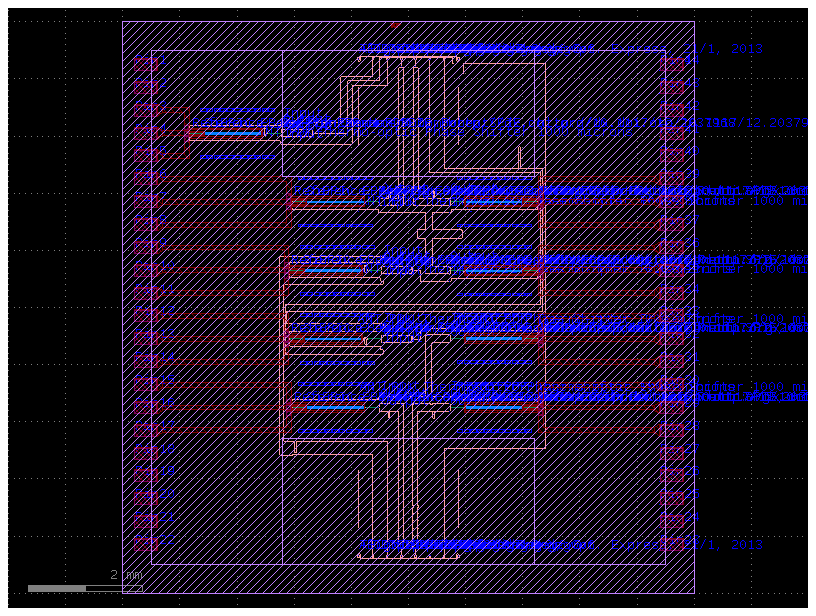

In [428]:
c.remove_layers(layers=[(1,10)])
c.plot()
c.show()

In [429]:
c.write_gds('CircuitoV1.gds')

WindowsPath('CircuitoV1.gds')